Maschinelles Lernen in Python  
in der Technischen Hochschule Deggendorf  

**Autor:**  
Atef Issaoui  
Berufsbegleitender Maschinenbaustudent  
Hochschule Rhein-Main  

# Predictive Maintenance – Scania Air Pressure System

### Allgemeine Informationen "aus Dataset Information":
**APS Failure and Operational Data for Scania Trucks** 
Die Daten stammen aus dem täglichen Betrieb von schweren Scania-LKWs und umfassen das Air Pressure System (APS). 

Es gibt 170 Attribute. Die Attribute sind anonymisiert und bestehen aus einzelnen numerischen Zahlen sowie Histogramm-Features im Format „Identifier_Bin”, die in Intervalle geteilt sind.Eine ziel Variable class (pos:APS ist defekt /neg:aps ist in Ordnung) 


es soll ein Modell aus Sensordaten von LKW (wirtschasftlich) vorhersagen,ob ein kritischer Fehler vorliegt um teure Ausfälle zu vermeiden Fehlende Werte sind notiert mit "na"

#### Link zum Dataset [UC irvine Machine Learning repositiy/ APS Failure at Scania Trucks-The datasets](https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks)

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import joblib

## 1. Erster Überblick und Datenstruktur

In [157]:
df_original = pd.read_csv(
    "aps_failure_training_set.csv",
    sep=",",
    na_values="na",# Fehlende Werte ersetzt mit nan
    skiprows=20,   
    engine="python")

In [184]:
df=df_original.copy()
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [185]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), object(1)
memory usage: 78.3+ MB


#### Interpretation:
Die Tabelle enthält 6000 Zeilen und 171 Spalten :  
- 1 Spalte hat den Datentyp `object` (Zielvariable `class`).  
- 169 Spalten haben den Datentyp `float64`.  
- 1 Spalte (`aa_000`) hat den Datentyp `int64`. [aa_000]  

In [186]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04
...,...,...,...,...,...,...,...,...
ee_007,59329.0,3.462714e+05,1.728056e+06,0.0,110.0,41098.0,167814.0,1.195801e+08
ee_008,59329.0,1.387300e+05,4.495100e+05,0.0,0.0,3812.0,139724.0,1.926740e+07
ee_009,59329.0,8.388915e+03,4.747043e+04,0.0,0.0,0.0,2028.0,3.810078e+06
ef_000,57276.0,9.057895e-02,4.368855e+00,0.0,0.0,0.0,0.0,4.820000e+02


#### Interpretation
- Sehr viele fehlende Werte (13.671 bis 60.000).
- Starke Unterschiede in den Wertebereichen (Min/Max).
- Mittelwert deutlich größer als Median → viele Ausreißer und rechtsschiefe Verteilungen.

In [187]:
int_columns = df.select_dtypes(include=['int64']).columns.tolist()
print(f"Spalten mit int64: {int_columns}")

Spalten mit int64: ['aa_000']


In [188]:
obj_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Spalten mit object : {obj_columns}")

Spalten mit object : ['class']


In [189]:
print(f"Der Datensatz hat {df.shape[0]} Zeilen und {df.shape[1]} Spalten.")

Der Datensatz hat 60000 Zeilen und 171 Spalten.


In [190]:
#  Verteilung der Zielklasse 
print("\nVerteilung der Zielvariable:")
print(df['class'].value_counts())


Verteilung der Zielvariable:
class
neg    59000
pos     1000
Name: count, dtype: int64


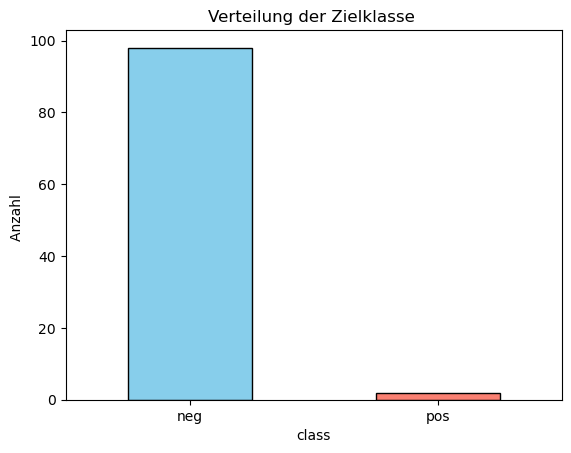

In [191]:
# Visualisierung
class_percent = round(df['class'].value_counts(normalize=True) * 100)
class_percent.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Verteilung der Zielklasse ')
plt.ylabel('Anzahl ')
plt.xticks(rotation=0)
plt.show()

In [192]:
unique_counts = df.drop(columns=['class']).nunique().sort_values()
print(unique_counts.head(5))
constant_columns = unique_counts[unique_counts <= 1].index.tolist()
print(f"\nKonstante Spalten: {constant_columns}")

cd_000     1
ch_000     2
as_000    21
ef_000    28
ab_000    29
dtype: int64

Konstante Spalten: ['cd_000']


In [193]:
df['cd_000']

0        1209600.0
1        1209600.0
2        1209600.0
3        1209600.0
4        1209600.0
           ...    
59995    1209600.0
59996    1209600.0
59997    1209600.0
59998    1209600.0
59999    1209600.0
Name: cd_000, Length: 60000, dtype: float64

In [194]:
df['ch_000']

0        0.0
1        NaN
2        0.0
3        0.0
4        0.0
        ... 
59995    0.0
59996    0.0
59997    0.0
59998    0.0
59999    0.0
Name: ch_000, Length: 60000, dtype: float64

#### Interpretation:
- Zielvaraible ist zwar vollgständig aber extrem ungleichmässig  
- [ch_000] (enthält nur 0 und NAN)--> --> für die weitere Analyse unbrauchbar
- [cd_000] (enthält ein wert 1209600)--> für die weitere Analyse unbrauchbar 

## 2 Explorative Datenanalyse

### 2.1 Train-Test-Split

In [195]:
X = df.drop("class", axis=1)
y = df["class"]
# Der Split: 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [196]:
X_train

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
39839,30606,NaN,3.260000e+02,226.0,0.0,0.0,0.0,0.0,0.0,0.0,...,290114.0,120320.0,246698.0,303534.0,228414.0,97398.0,60828.0,0.0,0.0,0.0
57649,314,0.0,1.400000e+01,14.0,0.0,0.0,0.0,0.0,0.0,2738.0,...,3222.0,1350.0,1632.0,1692.0,3288.0,2254.0,2.0,0.0,0.0,0.0
11862,3572,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,13308.0,7196.0,25950.0,117070.0,662.0,0.0,0.0,0.0,0.0,0.0
9381,33020,NaN,2.130706e+09,88.0,0.0,0.0,0.0,0.0,0.0,0.0,...,371136.0,185272.0,385210.0,329970.0,196806.0,82266.0,2992.0,0.0,0.0,0.0
43612,2518,NaN,5.000000e+01,34.0,0.0,0.0,0.0,0.0,1766.0,29390.0,...,9592.0,4752.0,13872.0,23130.0,29126.0,28378.0,88.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7551,62896,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,534132.0,312776.0,848610.0,781560.0,260320.0,87780.0,79738.0,1136.0,0.0,0.0
10579,52432,NaN,5.300000e+02,496.0,0.0,0.0,0.0,0.0,0.0,0.0,...,570110.0,268342.0,522602.0,414046.0,230436.0,125822.0,195024.0,18584.0,0.0,0.0
23126,6,NaN,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,48.0,4.0,10.0,20.0,50.0,68.0,0.0,0.0,0.0,0.0
56211,16,0.0,2.130706e+09,22.0,0.0,0.0,0.0,0.0,0.0,0.0,...,266.0,32.0,40.0,40.0,4.0,0.0,0.0,0.0,0.0,0.0


In [197]:
# Überprüfung der Verteilung 
print("Verteilung im Training (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nVerteilung im Test-Set (%):")
print(y_test.value_counts(normalize=True) * 100)

Verteilung im Training (%):
class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64

Verteilung im Test-Set (%):
class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64


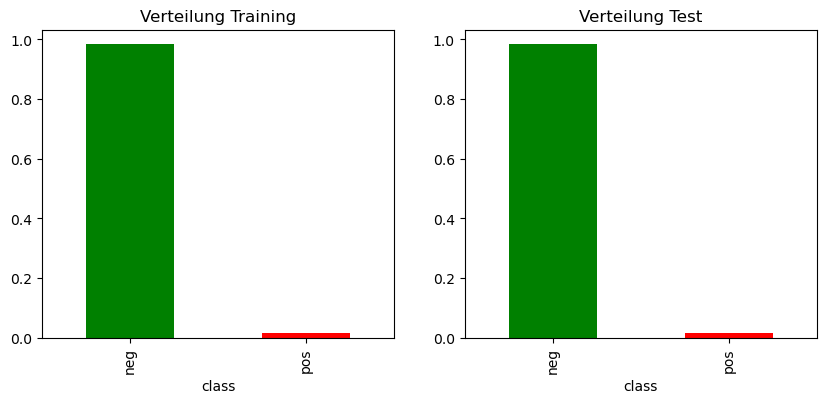

In [198]:
plt.figure(figsize=(10, 4))

# Diagramm 1: Training
plt.subplot(1, 2, 1)
y_train.value_counts(normalize=True).plot(kind='bar', color=['green', 'red'])
plt.title("Verteilung Training")

# Diagramm 2: Test
plt.subplot(1, 2, 2)
y_test.value_counts(normalize=True).plot(kind='bar', color=['green', 'red'])
plt.title("Verteilung Test")

plt.show()

#### Interpretation:
-  Daten wurden geteilt  80 % Training und 20 % Test.
- Test und trainingsdatensatz haben genau 1,6% defekte (neg.)

### 2.2 Explorative Datenanalyse

#### Korrelation der Top Sensoren

In [199]:
train_analysis = X_train.copy()
train_analysis['target'] = y_train.map({'neg': 0, 'pos': 1})
corr_matrix = train_analysis.corr()
top_correlations = corr_matrix['target'].sort_values(ascending=False)

print("Top 5 Sensoren mit der stärksten positiven Korrelation zum Defekt:")
print(top_correlations.head(5)) 

Top 5 Sensoren mit der stärksten positiven Korrelation zum Defekt:
target    1.000000
ci_000    0.550365
bb_000    0.540182
bv_000    0.539196
bu_000    0.539196
Name: target, dtype: float64


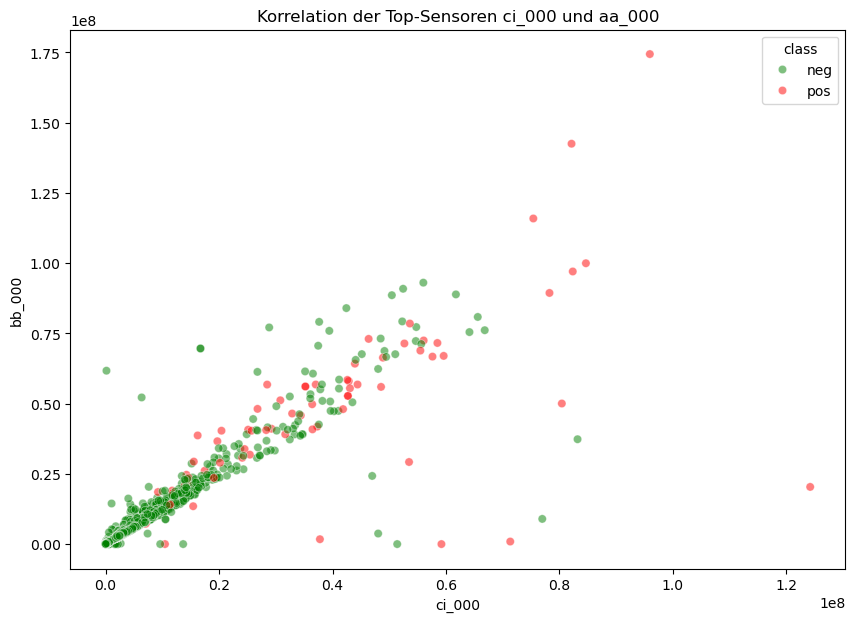

In [200]:
# Korrelation der 2 Top Sensoren
sample_df = X_train[['ci_000', 'bb_000']].copy()
sample_df['class'] = y_train
sample_df = sample_df.sample(5000, random_state=42)

plt.figure(figsize=(10, 7))

# Scatterplot der Top sensoren 
sns.scatterplot(data=sample_df, x='ci_000', y='bb_000', 
                hue='class', alpha=0.5, 
                palette={'neg': 'green', 'pos': 'red'})

plt.title("Korrelation der Top-Sensoren ci_000 und aa_000")
plt.show()

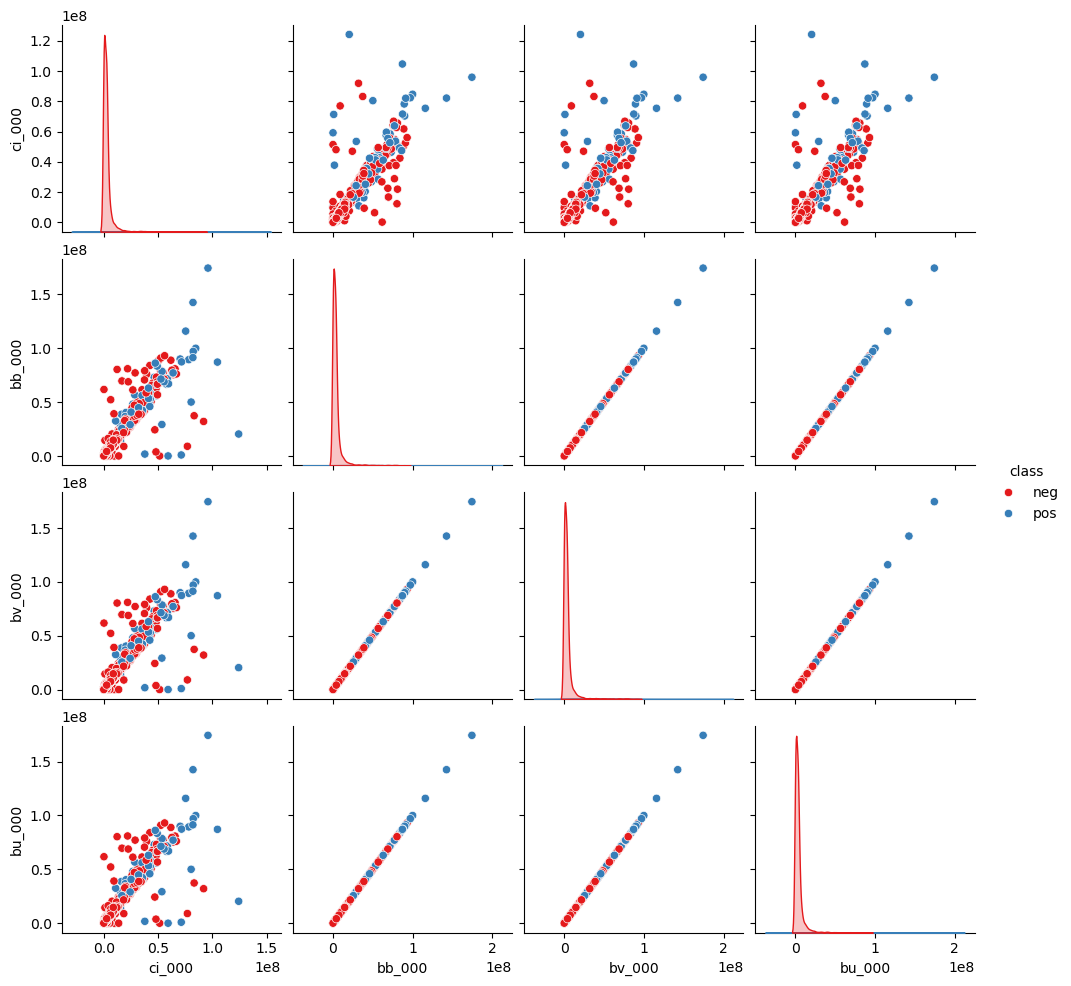

In [201]:
# Korrelation 4 Top-Sensoren
selected_sensors = ['ci_000', 'bb_000', 'bv_000', 'bu_000']
sample_df = X_train[selected_sensors].copy()
sample_df['class'] = y_train
sample_plot = sample_df.sample(6000, random_state=42)

sns.pairplot(sample_plot, hue='class', palette='Set1')

plt.show()

 Physikalische Messgrößen stehen häufig in Zusammenhang und korrelieren daher miteinander.
- Aufgrund der Anonymisierung lässt sich nicht erkennen, ob bestimmte Messgrößen mehrfach erfasst wurden.
- Der Pairplot zeigt deutliche Korrelationen zwischen den Sensoren.
- Daher sollten redundante Merkmale entfernt werden.

#### Fehlende Werte übersicht

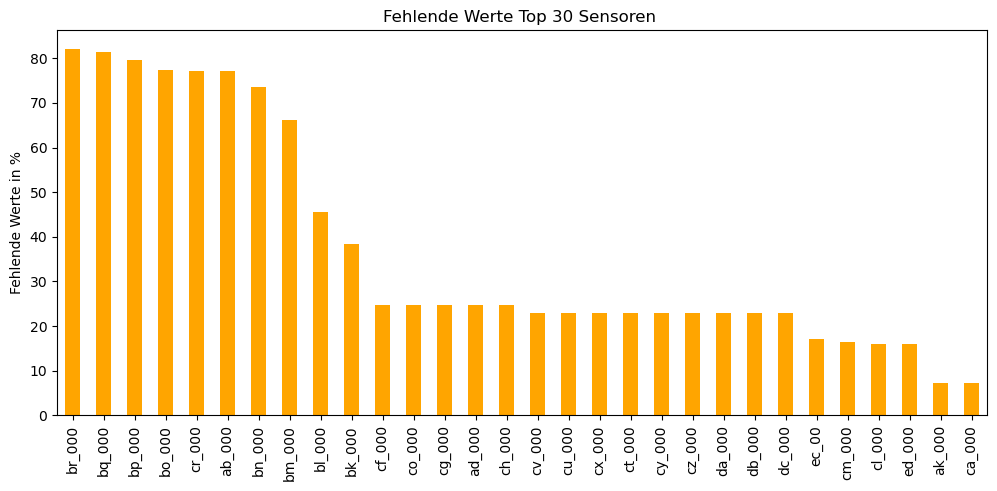

In [202]:
missing = X_train.isna().mean().sort_values(ascending=False) * 100
#  Plot für die Top 30 Sensoren
missing.head(30).plot(kind='bar', figsize=(12, 5), color='orange')

plt.title("Fehlende Werte Top 30 Sensoren ")
plt.ylabel("Fehlende Werte in %")
plt.show()

#### Stategie für die weitere Analyse:
Spalten mit sehr vielen fehlenden Werten, stark korrelierte Merkmale sowie Spalten mit konstanten oder nahezu konstanten Werten werden entfernt.
 Diese Merkmale liefern nur wenig zusätzliche Information und können die Leistung des Modells unnötig beeinflussen.

- a) Filter für fehlende Werte (> 10 %)

In [203]:
missing_percent = X_train.isna().mean() * 100
cols_missing_over_10 = missing_percent[missing_percent > 10].index.tolist()

X_temp = X_train.drop(columns=cols_missing_over_10)

print(f"Gefunden: {len(cols_missing_over_10)} Spalten mit > 10% Lücken")

Gefunden: 28 Spalten mit > 10% Lücken


- b) Filter für Konstanten spalten

In [204]:
cols_constant = [col for col in X_temp.columns if X_temp[col].nunique() <= 1]
X_temp = X_temp.drop(columns=cols_constant)

print(f"Gefunden: {len(cols_constant)} konstante Spalten.")

Gefunden: 1 konstante Spalten.


- c) Filter für hoch Redundanz 

In [205]:
# 1. Korrelation berechnen
corr_matrix = X_temp.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols_high_correlation = [column for column in upper.columns if any(upper[column] > 0.90)]

X_temp = X_temp.drop(columns=cols_high_correlation)

print(f"Gefunden: {len(cols_high_correlation)} hochkorrelierte Spalten.")


Gefunden: 35 hochkorrelierte Spalten.


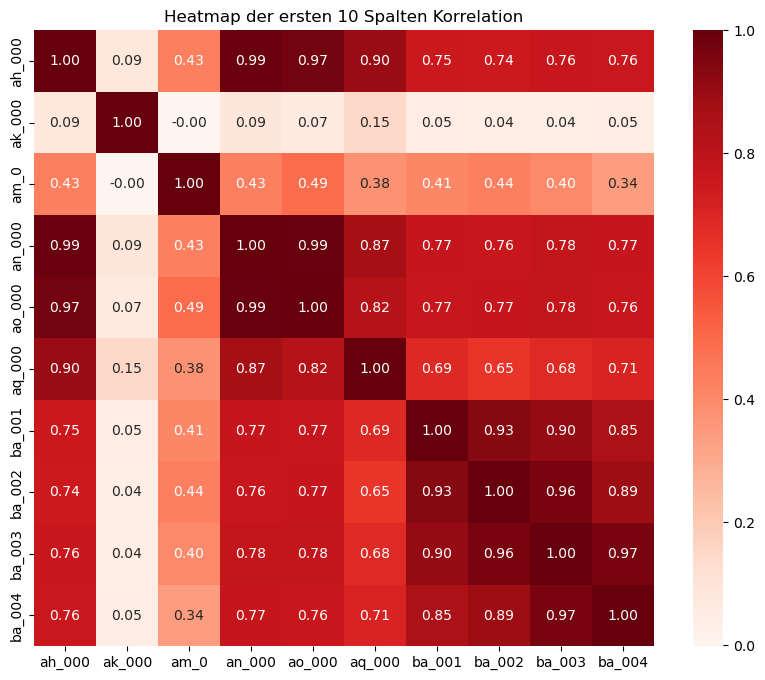

In [206]:
# Heatmap der ersten 10 Spalten aus der Liste
sample_redundant = cols_high_correlation[:10]
corr_sample = X_train[sample_redundant].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_sample, annot=True, cmap='Reds', fmt=".2f")

plt.title("Heatmap der ersten 10 Spalten Korrelation")
plt.show()

- d) Filter für Spalten mit fast den gleichen Werten

In [207]:
# Fast-Geister identifizieren
cols_near_constant = [col for col in X_temp.columns if X_temp[col].value_counts(normalize=True).values[0] > 0.995]

print(f"Gefunden: {len(cols_near_constant)} Spalten.")

Gefunden: 6 Spalten.


In [208]:
all_cols_to_drop = list(set(
    cols_missing_over_10 + 
    cols_constant + 
    cols_high_correlation + 
    cols_near_constant
))

# Das finale EDA
X_train_eda = X_train.drop(columns=all_cols_to_drop)

print(f"Zusammenfassung:")
print(f"Lücken (>10%):    {len(cols_missing_over_10)}")
print(f"Konstant:         {len(cols_constant)}")
print(f"Korreliert (>0.9): {len(cols_high_correlation)}")
print(f"Fast-Konstant:    {len(cols_near_constant)}")
print(f"-----------------------")
print(f"Gesamt gelöscht:  {len(all_cols_to_drop)}")
print(f"Sensoren übrig:   {X_train_eda.shape[1]}")

Zusammenfassung:
Lücken (>10%):    28
Konstant:         1
Korreliert (>0.9): 35
Fast-Konstant:    6
-----------------------
Gesamt gelöscht:  70
Sensoren übrig:   100


In [209]:
X_train_eda

,aa_000,ac_000,ae_000,af_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,...,dy_000,dz_000,ea_000,eb_000,ee_005,ee_006,ee_007,ee_008,ee_009,eg_000
39839,30606,3.260000e+02,0.0,0.0,0.0,0.0,0.0,514.0,124182.0,1318518.0,...,2942.0,0.0,0.0,281730.0,303534.0,228414.0,97398.0,60828.0,0.0,0.0
57649,314,1.400000e+01,0.0,0.0,0.0,0.0,2738.0,30998.0,10932.0,1936.0,...,0.0,0.0,0.0,0.0,1692.0,3288.0,2254.0,2.0,0.0,0.0
11862,3572,0.000000e+00,0.0,0.0,0.0,0.0,0.0,108.0,4288.0,106542.0,...,0.0,0.0,0.0,2571600.0,117070.0,662.0,0.0,0.0,0.0,0.0
9381,33020,2.130706e+09,0.0,0.0,0.0,0.0,0.0,124.0,90494.0,1395822.0,...,0.0,0.0,0.0,3424640.0,329970.0,196806.0,82266.0,2992.0,0.0,0.0
43612,2518,5.000000e+01,0.0,0.0,0.0,1766.0,29390.0,61622.0,41142.0,44574.0,...,150.0,0.0,0.0,1518170.0,23130.0,29126.0,28378.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7551,62896,0.000000e+00,0.0,0.0,0.0,0.0,0.0,328.0,476870.0,2943682.0,...,0.0,0.0,0.0,4141730.0,781560.0,260320.0,87780.0,79738.0,1136.0,0.0
10579,52432,5.300000e+02,0.0,0.0,0.0,0.0,0.0,1952.0,401248.0,2427556.0,...,0.0,0.0,0.0,3752650.0,414046.0,230436.0,125822.0,195024.0,18584.0,0.0
23126,6,0.000000e+00,0.0,0.0,0.0,0.0,0.0,138.0,2060.0,902.0,...,8.0,0.0,0.0,0.0,20.0,50.0,68.0,0.0,0.0,0.0
56211,16,2.130706e+09,0.0,0.0,0.0,0.0,0.0,12.0,3638.0,3640.0,...,58.0,0.0,0.0,0.0,40.0,4.0,0.0,0.0,0.0,0.0


In [210]:
# Prüfung wieviel 0 Werte hat die Spalte ae_000
print(f"Werte ungleich Null in ag_005: {(X_train_eda['ae_000'] != 0).sum()}")

Werte ungleich Null in ag_005: 3554


### Korrelation erneut prüfen

In [211]:
y_train_num = y_train.map({'neg': 0, 'pos': 1})
correlations = X_train_eda.corrwith(y_train_num).sort_values(ascending=False)

#  Top 10 Sensoren 
print("Top 10 Sensoren mit der stärksten Korrelation zum Defekten APS")
print(correlations.head(10))


Top 10 Sensoren mit der stärksten Korrelation zum Defekten APS
aa_000    0.530675
ap_000    0.515509
bx_000    0.510024
ee_005    0.482778
ck_000    0.470537
ag_005    0.443481
cs_004    0.437689
ba_000    0.429445
ag_003    0.427375
az_005    0.426153
dtype: float64


In [212]:
top_6 = ['aa_000', 'ap_000', 'bx_000', 'ee_005', 'ck_000','ag_005']
plot_df = X_train[top_6].copy()
plot_df['class'] = y_train
melted_df = plot_df.melt(id_vars='class', var_name='sensor', value_name='wert')

In [213]:
melted_df.head(10)

,class,sensor,wert
0,neg,aa_000,30606.0
1,neg,aa_000,314.0
2,neg,aa_000,3572.0
3,neg,aa_000,33020.0
4,neg,aa_000,2518.0
5,neg,aa_000,183156.0
6,neg,aa_000,57688.0
7,neg,aa_000,30424.0
8,neg,aa_000,1118.0
9,neg,aa_000,40706.0


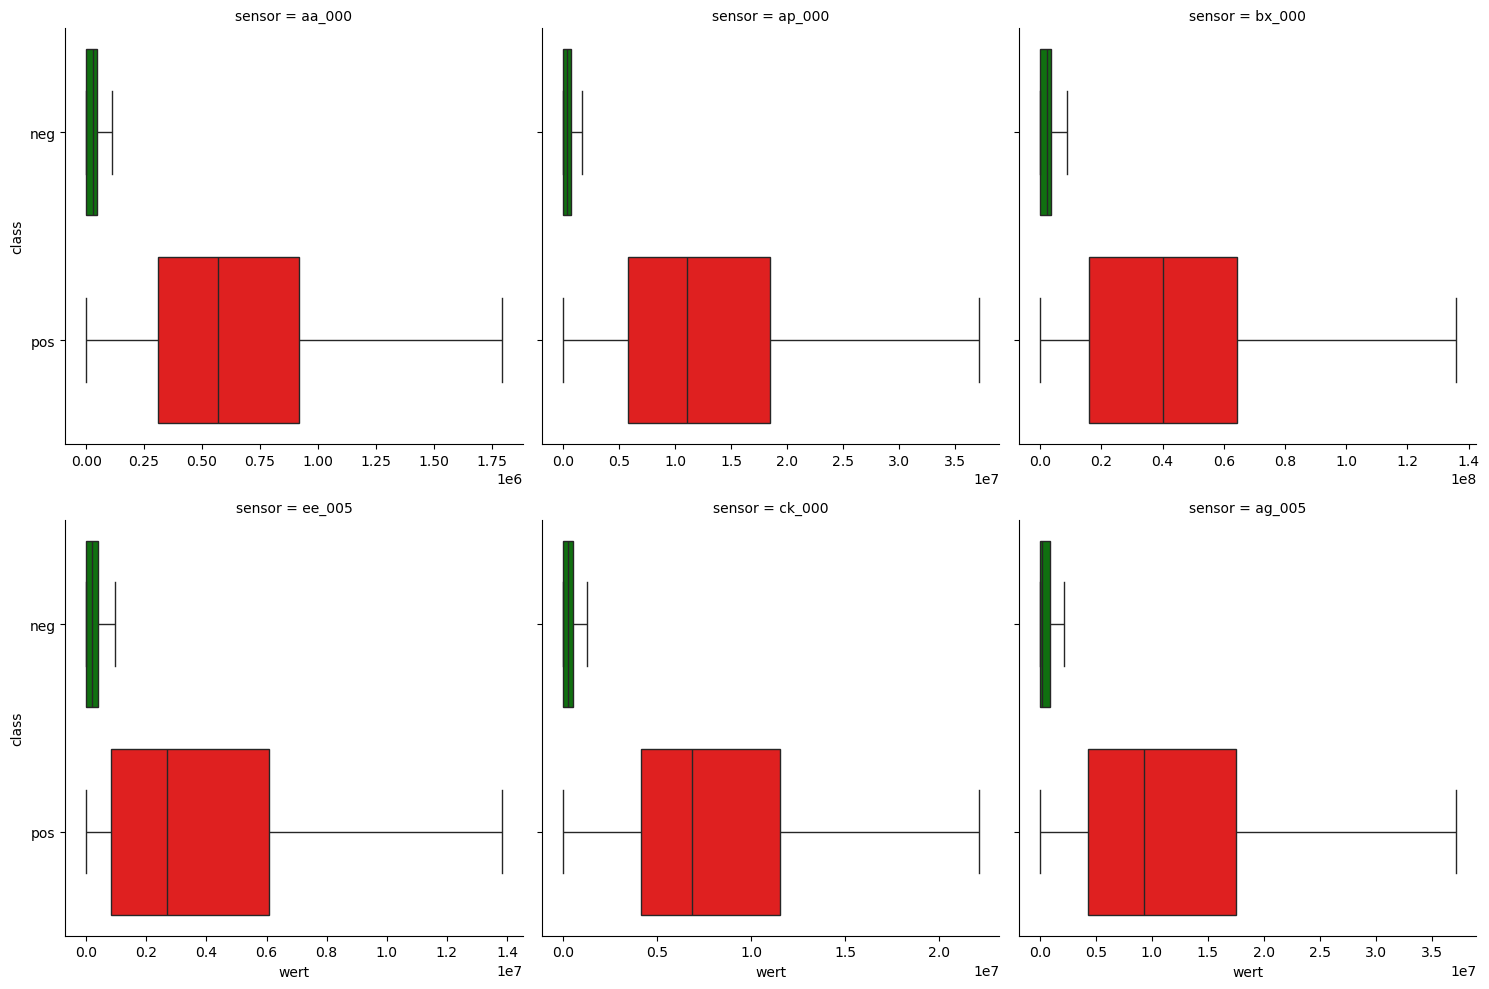

In [214]:
# Plot
sns.catplot(data=melted_df, x='wert', y='class', col='sensor', kind='box', 
            hue='class', palette={'neg': 'green', 'pos': 'red'}, 
            col_wrap=3, sharex=False, showfliers=False)
plt.show()

#### die gefilterten Splaten zeigen klare trennung zwischen Defekten und nicht Defekten APS
-  (pos.) liegen fast immer im oberen Bereich 
-  Auch nach der deutlichen Reduzierung der Anzahl der Merkmale zeigen viele Spalten weiterhin sehr ähnliche Informationen.

In [136]:
# Top 5 Sensoren
top_5 = ['aa_000', 'ap_000', 'bx_000', 'ee_005', 'ck_000']
#  Stichprobe aus 2000 Zeilen
sample_df = X_train[top_5].copy()
sample_df['class'] = y_train
sample_plot = sample_df.sample(2000, random_state=42)
sample_plot.head()

,aa_000,ap_000,bx_000,ee_005,ck_000,class
41636,87540,1389254.0,8283526.0,432002.0,1976034.24,neg
8684,26036,240748.0,1669308.0,181176.0,152916.48,neg
26662,178520,1124164.0,10841954.0,2337750.0,608630.40,neg
6139,38498,454900.0,2644052.0,363654.0,250174.08,neg
158,16,14622.0,29032.0,86.0,1401.60,neg


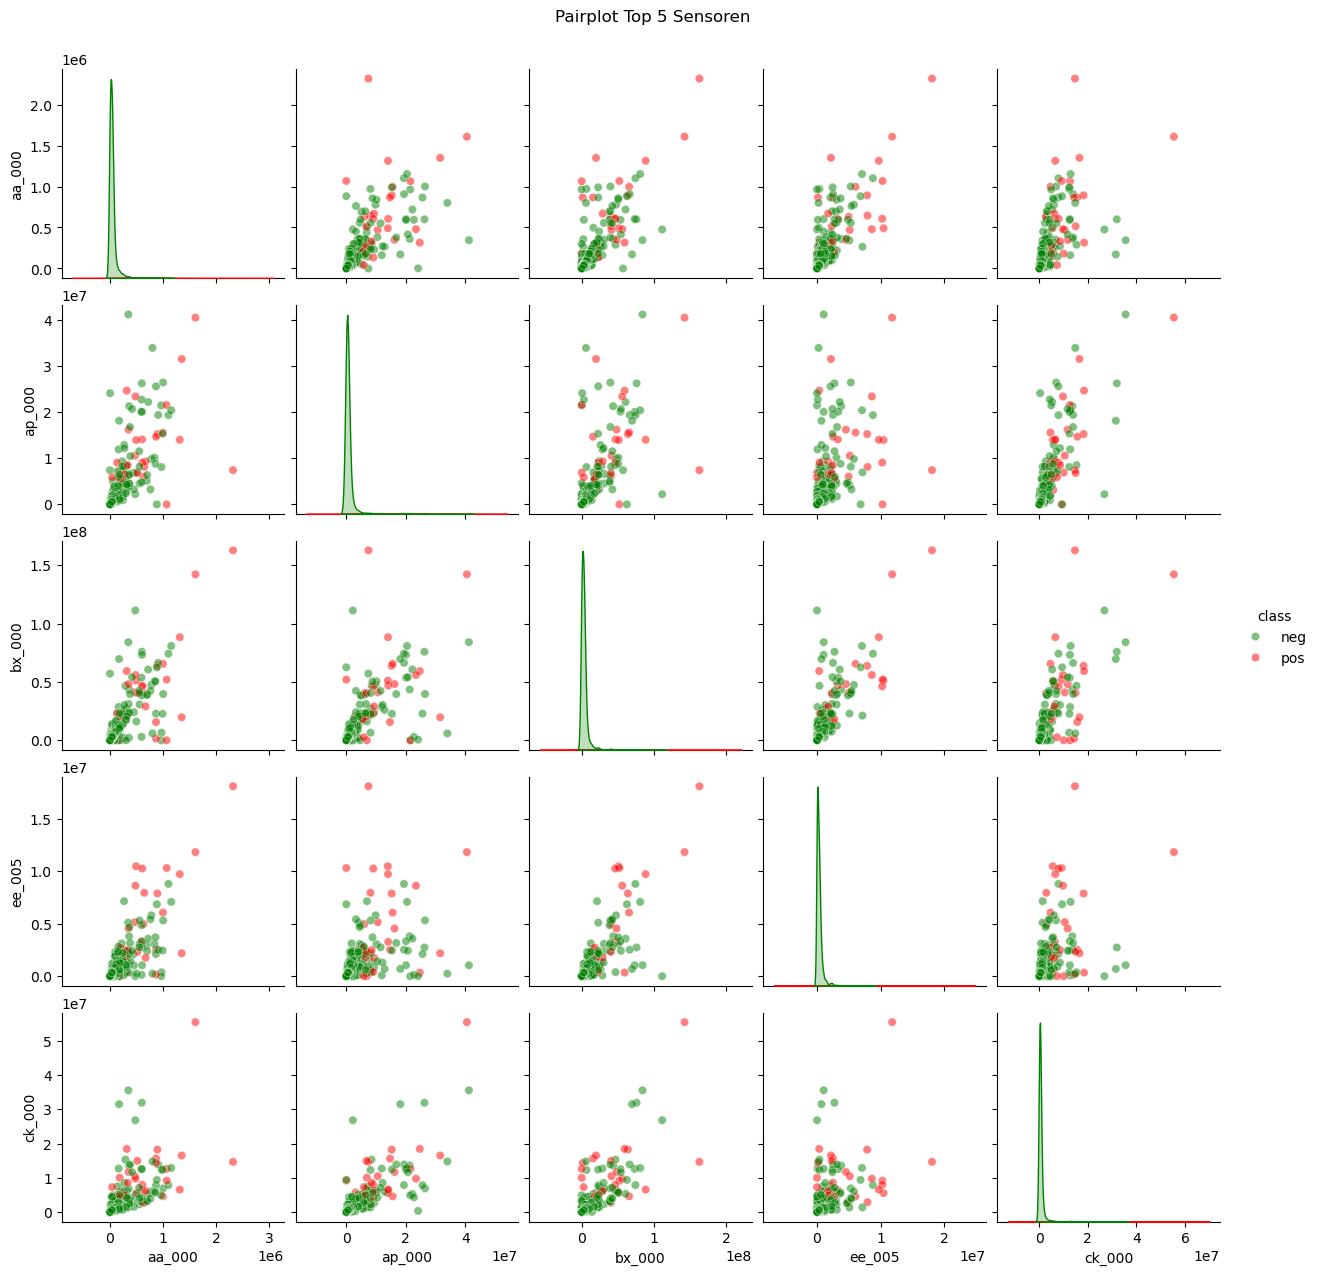

In [137]:
sns.pairplot(sample_plot, hue='class', 
             palette={'neg': 'green', 'pos': 'red'}, 
             diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle("Pairplot Top 5 Sensoren", y=1.02)
plt.show()

- Eine erneute Prüfung der Korrelation zeigt, dass kaum noch Zusammenhänge zwischen den Merkmalen bestehen.

#### Ausgewählte Sensoren Plots

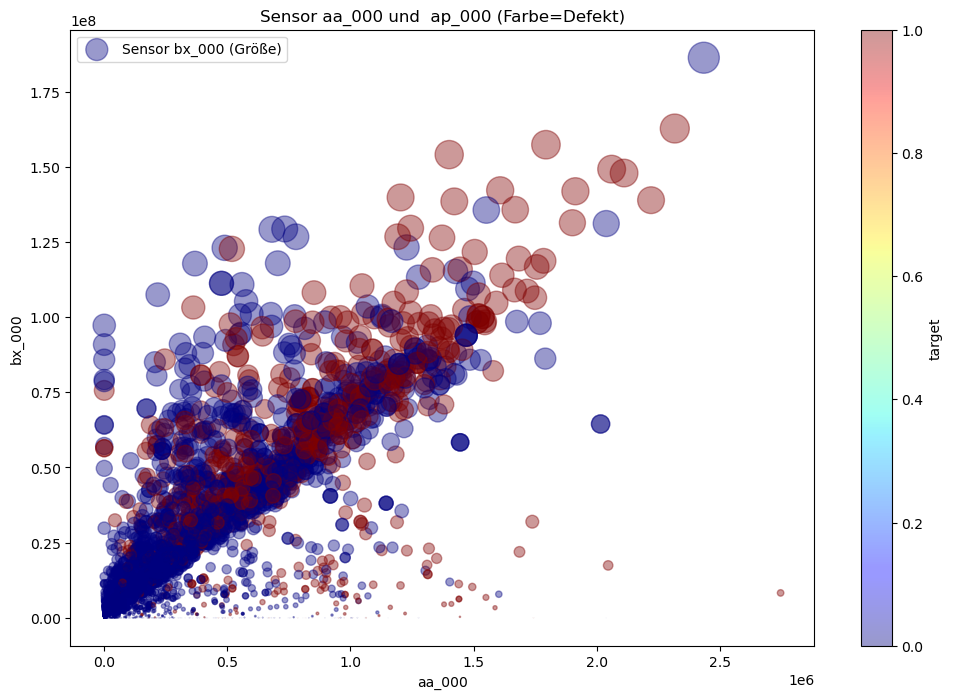

In [215]:
#  temporäre Kopie für den Plot
plot_df = X_train_eda[['aa_000', 'ap_000', 'bx_000']].copy()
plot_df['target'] = y_train.map({'neg': 0, 'pos': 1})


plot_df.plot(kind="scatter", 
             x="aa_000", 
             y="bx_000", 
             alpha=0.4,
             #  skalierung
             s=plot_df["bx_000"] / plot_df["bx_000"].max() * 500, 
             label="Sensor bx_000 (Größe)", 
             c="target", 
             cmap=plt.get_cmap("jet"), 
             colorbar=True, 
             figsize=(12, 8))

plt.title("Sensor aa_000 und  ap_000 (Farbe=Defekt)")
plt.legend()
plt.show()

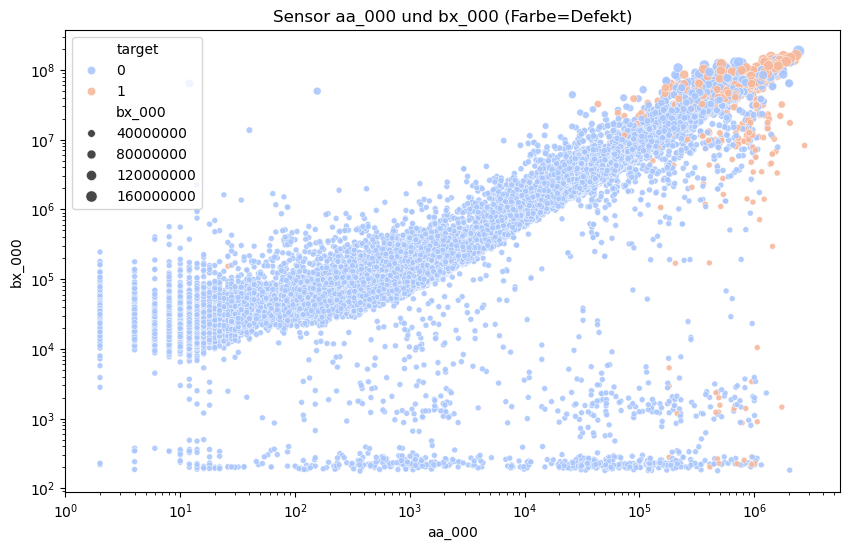

In [216]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='aa_000', y='bx_000', hue='target', 
                size='bx_000', alpha=0.9, palette='coolwarm')
 
plt.loglog()
plt.title("Sensor aa_000 und bx_000 (Farbe=Defekt)")
plt.show()

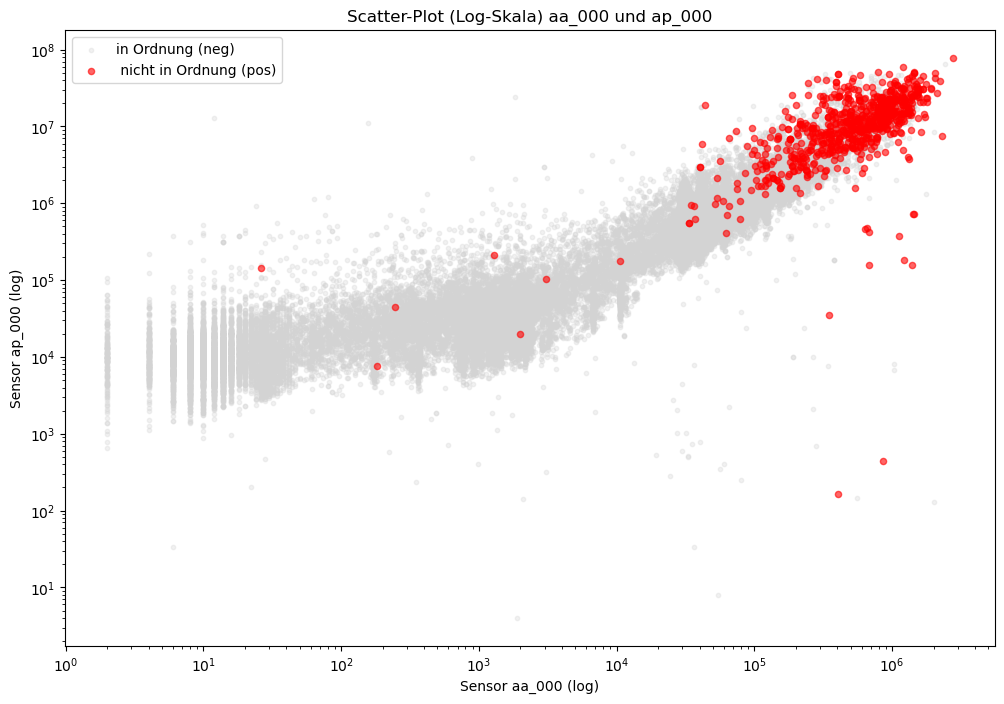

In [217]:

neg_data = plot_df[plot_df['target'] == 0]
pos_data = plot_df[plot_df['target'] == 1]

plt.figure(figsize=(12, 8))

#  in Ordnung (neg.)
plt.scatter(neg_data["aa_000"], neg_data["ap_000"], 
            color="lightgrey", alpha=0.3, s=10, label="in Ordnung (neg)")

#  nicht in Ordnung (pos.)
plt.scatter(pos_data["aa_000"], pos_data["ap_000"], 
            color="red", alpha=0.6, s=20, label=" nicht in Ordnung (pos)")

# 3. Logarithmische Skalierung
plt.xscale('log')
plt.yscale('log')

plt.title("Scatter-Plot (Log-Skala) aa_000 und ap_000")
plt.xlabel("Sensor aa_000 (log)")
plt.ylabel("Sensor ap_000 (log)")
plt.legend()
plt.show()

- Die selektierten und bereinigten Attribute zeigen eine klare Trennung zwischen positiven und negativen Klassen
-  Die Defekten (pos.) bilden eine Wolke im oberen Bereich
- Die Ergebnisse sind versprechend, da das Modell defekte APS eindeutig erkennen kann.

## 3. Datenvorverarbeitung 

### 3.1 Tranformer

In [218]:
class IQRTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.quantiles_ = None
        self.iqr_ = None
        
    def fit(self, X, y=None):
        # Berechnet das 25. und 75. Perzentil für jede Spalte
        self.quantiles_ = np.nanpercentile(X, [25.0, 75.0], axis=0)
        self.iqr_ = self.quantiles_[1] - self.quantiles_[0]
        return self
  
    def transform(self, X):
        
        X_array = np.array(X)
        X_transformed = np.copy(X_array)
        
        for feature in range(X_transformed.shape[1]):
            # Grenzen berechnen
            lower_bound = self.quantiles_[0, feature] - 1.5 * self.iqr_[feature]
            upper_bound = self.quantiles_[1, feature] + 1.5 * self.iqr_[feature]
            # Werte begrenzen
            X_transformed[:, feature] = np.clip(X_transformed[:, feature], lower_bound, upper_bound)
            
        return X_transformed

In [219]:
# TRANSFORMER 2
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, missing_threshold=10, corr_threshold=0.90, var_threshold=0.995):
        self.missing_threshold = missing_threshold
        self.corr_threshold = corr_threshold
        self.var_threshold = var_threshold
        self.cols_to_drop_ = []

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        # 1. Lücken finden
        m = X_df.isna().mean() * 100
        gap_cols = m[m > self.missing_threshold].index.tolist()
        # 2. Konstanten Spalten finden
        temp = X_df.drop(columns=gap_cols)
        const_cols = [c for c in temp.columns if temp[c].nunique() <= 1]
        temp = temp.drop(columns=const_cols)
        near_const = [c for c in temp.columns if temp[c].value_counts(normalize=True).values[0] > self.var_threshold]
        # 3. Korrelation finden
        temp = temp.drop(columns=near_const)
        corr = temp.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        high_corr = [col for col in upper.columns if any(upper[col] > self.corr_threshold)]
        
        self.cols_to_drop_ = list(set(gap_cols + const_cols + near_const + high_corr))
        return self

    def transform(self, X):
        return pd.DataFrame(X).drop(columns=self.cols_to_drop_)

### 3.2 Full Pipeline

In [220]:
# DIE FULL PIPELINE
full_pipeline = Pipeline([
    ('selector', FeatureDropper()), 
    ('outlier', IQRTransformer()),       
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())         
])

### 3.3 Anwendung der Pipeline

In [221]:
# Anwendung der Pipeline
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

#  Zielvariable  umwandeln
y_train_num = y_train.map({'neg': 0, 'pos': 1})
y_test_num = y_test.map({'neg': 0, 'pos': 1})

print(f"Vollständige Pipeline ausgeführt!")
print(f"Trainingsdaten bereit: {X_train_prepared.shape}")
print(f"Testdaten bereit: {X_test_prepared.shape}")

Vollständige Pipeline ausgeführt!
Trainingsdaten bereit: (48000, 100)
Testdaten bereit: (12000, 100)


#### Die vollständige Pipeline hat wie in der EDA-Analyse erfolgreich funktioniert:
Zunächst wurden Spalten mit mehr als 10 % fehlenden Werten
sowie konstante, nahezu konstante und stark korrelierte Spalten entfernt.  
Im Anschluss erfolgte die Datenaufbereitung der verbleibenden Spalten (100 Splaten):  

+ Ausreißerbehandlung
+ Median-Imputation fehlender Werte
+  Standardrisierung.

## 4. Modellierung und Auswahl

### 4.1 Modell 1 (z.B. Random Forest):

In [222]:
from sklearn.ensemble import RandomForestClassifier

# 1. Modell erstellen
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Modell trainieren
rf_clf.fit(X_train_prepared, y_train_num)

print("Modell 1 (Random Forest) wurde erfolgreich trainiert!")

Modell 1 (Random Forest) wurde erfolgreich trainiert!


#### 4.1.1 Bewertung

In [223]:
#  Vorhersage erstellen
y_pred_train = rf_clf.predict(X_train_prepared)
#  Bericht anzeigen
print(" Classification Report (Training)")
print(classification_report(y_train_num, y_pred_train, target_names=['neg', 'pos']))



 Classification Report (Training)
              precision    recall  f1-score   support

         neg       1.00      1.00      1.00     47200
         pos       1.00      1.00      1.00       800

    accuracy                           1.00     48000
   macro avg       1.00      1.00      1.00     48000
weighted avg       1.00      1.00      1.00     48000



- Trainingsdatensatz mit 47200 (neg.) und 800 (pos.) wurde trainiert 
- Das Modell hat alle 800 defekten LKWs erkannt (recall=1)
--> Overfitting


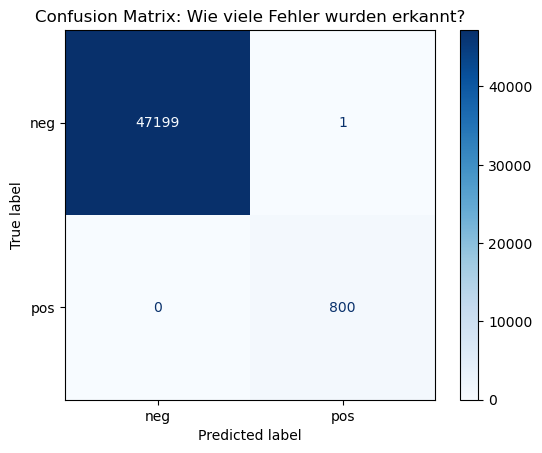

In [224]:
# 3. Confusion Matrix visualisieren
disp = ConfusionMatrixDisplay.from_predictions(y_train_num, y_pred_train, 
                                               display_labels=['neg', 'pos'], 
                                               cmap='Blues')
plt.title("Confusion Matrix: Wie viele Fehler wurden erkannt?")
plt.show()

Auswertung:
- 47199 LKWs sind in Ordnung und das Modell hat sie richtig als in Ordnung erkannt
- 800 LKWs sind defekt und wurden als defekt erkannt
- 1 LKW in Ordnung und wurde als defekt erkannt

### 4.1.2: Kreuzvalidierung

In [225]:
from sklearn.model_selection import cross_val_score
# cv=5  5 Testrunden.
recall_scores = cross_val_score(rf_clf, X_train_prepared, y_train_num, cv=5, scoring='recall')

print(f"Recall-Werte der 5 Runden: {recall_scores}")
print(f"Durchschnittlicher Recall: {recall_scores.mean():.4f}")

Recall-Werte der 5 Runden: [0.5     0.45625 0.39375 0.51875 0.525  ]
Durchschnittlicher Recall: 0.4788


- Das Modell übersieht mehr als die Hälfte (48 %) aller defekten LKWs 

#### 4.1.3 Feintuning (GridSearchCV) 

In [227]:
from sklearn.model_selection import GridSearchCV

#  Hyperparameter
param_grid = [
    {
        'n_estimators': [50, 100],      # Anzahl der Bäume
        'max_depth': [10, 20, None],    #  Bäumentiefe 
        'class_weight': ['balanced']    # balanced da die Datenungleich sind
    }
]
# optimieren gezielt mit recall
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                           param_grid, cv=3, scoring='recall', n_jobs=-1)

grid_search.fit(X_train_prepared, y_train_num)

# Ergebnisse 
print(f"Beste Einstellungen: {grid_search.best_params_}")
print(f"Bester Recall-Score aus dem Tuning: {grid_search.best_score_:.4f}")

# Das beste Modell
final_rf_model = grid_search.best_estimator_

Beste Einstellungen: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 50}
Bester Recall-Score aus dem Tuning: 0.8175


- Durch das Feintuning wurde den Recall von 48 % auf fast 82 % gesteigert

In [229]:
final_rf_model = grid_search.best_estimator_

# Vorhersage auf den Trainingsdaten
y_pred_tuned = final_rf_model.predict(X_train_prepared)

#  Vollständiger Bericht
print("Bericht für das getunte Random Forest Modell")
print(classification_report(y_train_num, y_pred_tuned, target_names=['neg', 'pos']))

Bericht für das getunte Random Forest Modell
              precision    recall  f1-score   support

         neg       1.00      0.97      0.99     47200
         pos       0.37      0.99      0.54       800

    accuracy                           0.97     48000
   macro avg       0.68      0.98      0.76     48000
weighted avg       0.99      0.97      0.98     48000



- Recall (0.99) :Das Modell entdeckt 99% aller defekten LKWs
- precision (0,37): 63% der Fälle wurden falsch deklariert 

Confusion Matrix: Getunter Random Forest (Training)


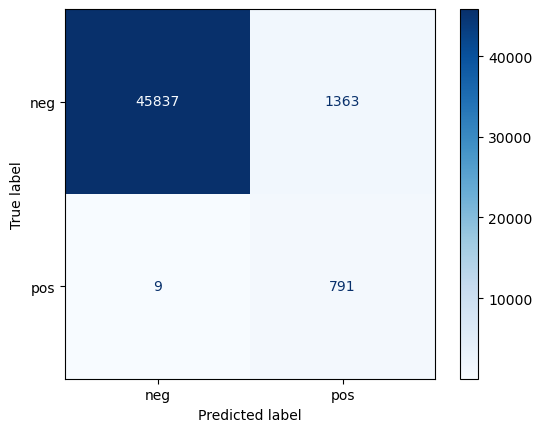

In [230]:
print("Confusion Matrix: Getunter Random Forest (Training)")
ConfusionMatrixDisplay.from_predictions(y_train_num, y_pred_tuned, 
                                         display_labels=['neg', 'pos'], 
                                         cmap='Blues')
plt.show()

Auswertung:
- großenteil der nicht defekten LKws wurden erkannt
- fast alle defekten APS 791 (von 800) wurden erkannt
- 1363 sind Fehlalarme
- 9 defekten APS wurden übersehen

## 4.2 Modell 2 Naive Bayes

In [232]:
from sklearn.naive_bayes import GaussianNB
# Modell erstellen
gnb_clf = GaussianNB()
#  Modell trainieren
gnb_clf.fit(X_train_prepared, y_train_num)

print("Modell 2 (Naive Bayes) erfolgreich trainiert!")

Modell 2 (Naive Bayes) erfolgreich trainiert!


### 4.2.1: Bewertung GaussianNB

In [233]:
# Vorhersage erstellen
y_pred_gnb = gnb_clf.predict(X_train_prepared)
# Bericht 
print("Classification Report (Naive Bayes - Training)")
print(classification_report(y_train_num, y_pred_gnb, target_names=['neg', 'pos']))



Classification Report (Naive Bayes - Training)
              precision    recall  f1-score   support

         neg       1.00      0.88      0.93     47200
         pos       0.11      0.90      0.19       800

    accuracy                           0.88     48000
   macro avg       0.55      0.89      0.56     48000
weighted avg       0.98      0.88      0.92     48000



Auswertung:
-  recall 0.90: 90 % der defekten LKWs werden entdeckt
-  precision 0.11: Von allen LKWs, die das Modell als „defekt“ markiert hat, waren nur 11 % wirklich defekt
-  89 % der Alarme waren Fehlalarme
-  accuracy 0.88 . liegt niedriger als Random Forest 97%

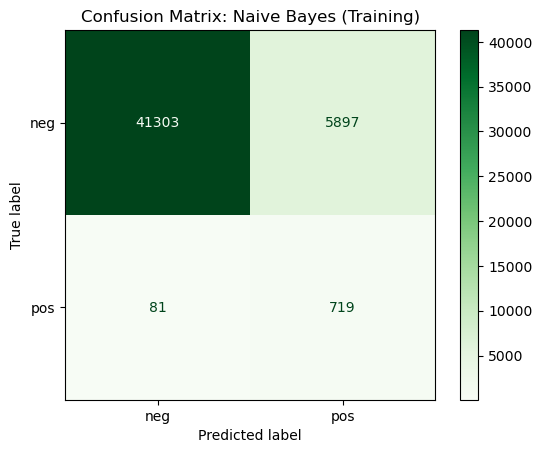

In [234]:
# Confusion Matrix 
ConfusionMatrixDisplay.from_predictions(y_train_num, y_pred_gnb, 
                                         display_labels=['neg', 'pos'], 
                                         cmap='Greens')
plt.title("Confusion Matrix: Naive Bayes (Training)")
plt.show()

#### Auswertung:
- 41303 nicht defekt APS wurden richtig als nicht defekt erkannt
- 719 defekt APS wurden richtig als deffekt erkannt 
- 5897 nicht defekt APS wurden als defekt erkannt
- 81 defekte APS wurden nicht erkannt 

### 4.2.2: Kreuzvalidierung 

In [235]:
from sklearn.model_selection import cross_val_score
# Kreuzvalidierung für Naive Bayes (Recall)
gnb_recall_cv = cross_val_score(gnb_clf, X_train_prepared, y_train_num, cv=5, scoring='recall')

print(f"Naive Bayes Recall-Werte (CV): {gnb_recall_cv}")
print(f"Durchschnittlicher Recall: {gnb_recall_cv.mean():.4f}")

Naive Bayes Recall-Werte (CV): [0.875   0.8875  0.89375 0.89375 0.9375 ]
Durchschnittlicher Recall: 0.8975


#### Auswertung:
- Naive Bayes bleibt bei ca.  Recall 90% stabil 
- 90% der defekten teile werden erkannt

### 4.2.3: Feintuning (Naive Bayes)

In [236]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
#  Suchbereich
params = {'var_smoothing': uniform(1e-11, 1e-8)}

# 100 Versuche, optimiert auf Recall
rs_gnb = RandomizedSearchCV(gnb_clf, param_distributions=params, 
                            n_iter=100, cv=5, scoring='recall', random_state=42, n_jobs=-1)

# 3. Suche starten
rs_gnb.fit(X_train_prepared, y_train_num)

print(f"Beste Parameter: {rs_gnb.best_params_}")
print(f"Bester Recall nach Tuning: {rs_gnb.best_score_:.4f}")

# Modell speichern
final_gnb_model = rs_gnb.best_estimator_

Beste Parameter: {'var_smoothing': np.float64(3.7554011884736245e-09)}
Bester Recall nach Tuning: 0.8975


### 4.3 Kreuzvalidierung für alle Modelle

In [237]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Kreuzvalidierung für Accuracy 
acc_gnb = cross_val_score(gnb_clf, X_train_prepared, y_train_num, scoring="accuracy", cv=5)
acc_rf = cross_val_score(rf_clf, X_train_prepared, y_train_num, scoring="accuracy", cv=5)

# 2. Kreuzvalidierung für Recall ( für Defekte)
rec_gnb = cross_val_score(gnb_clf, X_train_prepared, y_train_num, scoring="recall", cv=5)
rec_rf = cross_val_score(rf_clf, X_train_prepared, y_train_num, scoring="recall", cv=5)

# Übersicht
print("MODELLVERGLEICH (Mittelwerte aus 5 Folds)")
print(f"Modell\t\t Accuracy\t Recall (pos)")
print(f"Naive Bayes\t {np.mean(acc_gnb):.4f}\t\t {np.mean(rec_gnb):.4f}")
print(f"Random Forest\t {np.mean(acc_rf):.4f}\t\t {np.mean(rec_rf):.4f}")

MODELLVERGLEICH (Mittelwerte aus 5 Folds)
Modell		 Accuracy	 Recall (pos)
Naive Bayes	 0.8757		 0.8975
Random Forest	 0.9900		 0.4788


#### Vergleich der beiden Modelle 
- Random Forest :
 nicht defekten LKWs (neg) wurden zu 99 % erkannt
aber defekten LKWs nur zu 47%  erkannt
- Naive Bayes: 
 nicht defekten LKWs (neg) werden zu 87,5 % erkannt
 aber defekten LKWs  zu 89,7 %  erkannt
- Naive Bayes findet insgesamt fast 90% der Defekten LKW (recall 98,7%) und schneidet besser als random Forest

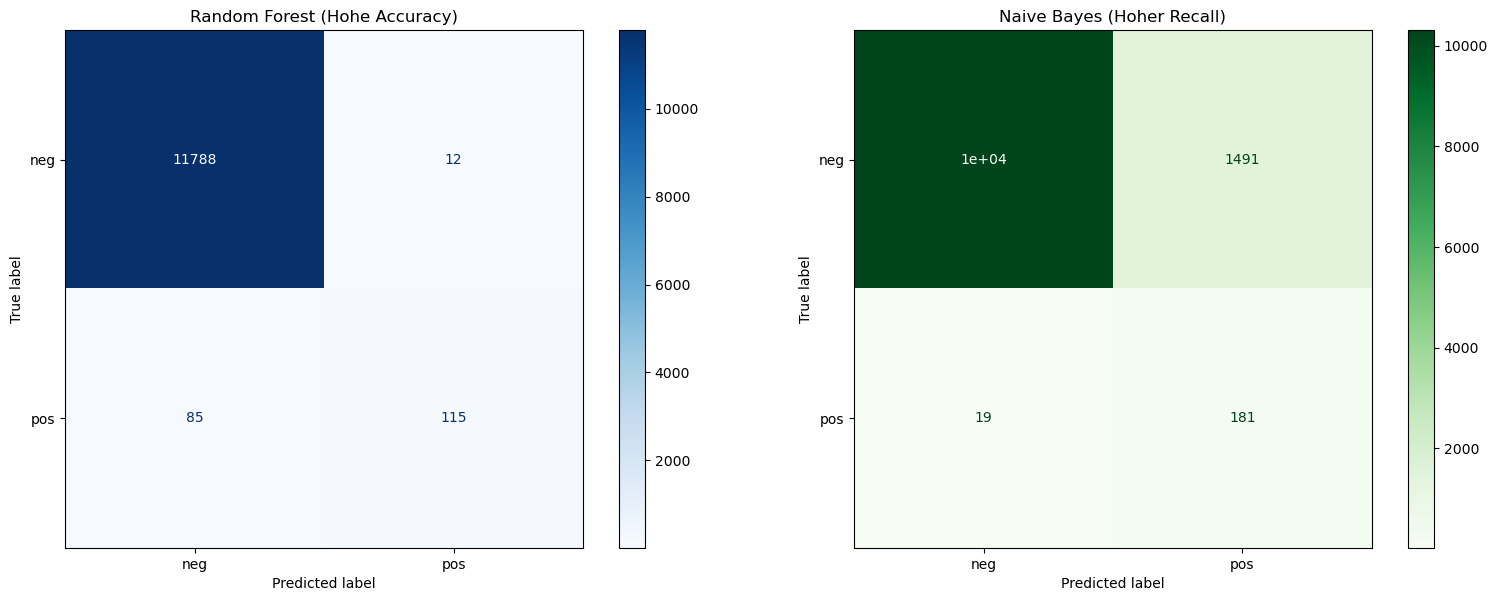

In [238]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#  Confusion Matrix für den Random Forest 
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test_prepared, y_test_num, 
                                      display_labels=['neg', 'pos'], 
                                      cmap='Blues', ax=ax[0])
ax[0].set_title("Random Forest (Hohe Accuracy)")

# 2. Confusion Matrix für Naive Bayes 
ConfusionMatrixDisplay.from_estimator(final_gnb_model, X_test_prepared, y_test_num, 
                                      display_labels=['neg', 'pos'], 
                                      cmap='Greens', ax=ax[1])
ax[1].set_title("Naive Bayes (Hoher Recall)")

plt.tight_layout()
plt.show()

### 5 Evaluation des finalen Modells (Prüfung auf den Testdaten)

In [239]:
#  Vorhersage auf den  Testdaten
y_test_pred = final_gnb_model.predict(X_test_prepared)
#  Der finale Bericht 
print(" FINALES ERGEBNIS AUF DEN TESTDATEN ")
print(classification_report(y_test_num, y_test_pred, target_names=['neg', 'pos']))



 FINALES ERGEBNIS AUF DEN TESTDATEN 
              precision    recall  f1-score   support

         neg       1.00      0.87      0.93     11800
         pos       0.11      0.91      0.19       200

    accuracy                           0.87     12000
   macro avg       0.55      0.89      0.56     12000
weighted avg       0.98      0.87      0.92     12000



- 91% der defekten LKWs wurden im Test Datensatz gefunden (recall)

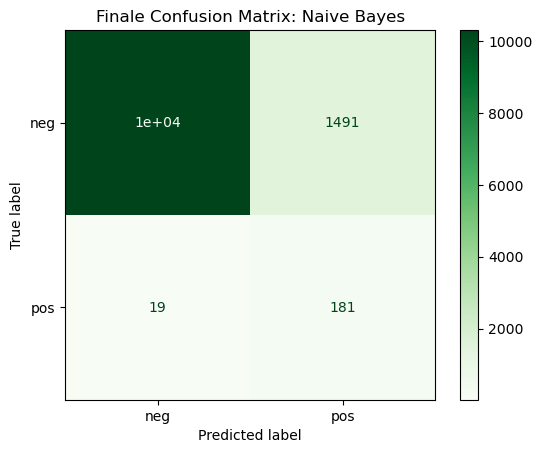

In [240]:
ConfusionMatrixDisplay.from_predictions(y_test_num, y_test_pred, 
                                         display_labels=['neg', 'pos'], cmap='Greens')
plt.title("Finale Confusion Matrix: Naive Bayes")
plt.show()

-  von 200 defekten LKWs wurden 181 erkannt und nur 19 durchgegangen

# 6. Abspeichern des trainierten Modells und erneut testen 

In [241]:
joblib.dump(final_gnb_model, "scania_aps_model_gnb.pkl")
joblib.dump(full_pipeline, "scania_aps_pipeline.pkl")

['scania_aps_pipeline.pkl']

In [242]:
loaded_model = joblib.load("scania_aps_model_gnb.pkl")
loaded_pipeline = joblib.load("scania_aps_pipeline.pkl")

In [243]:
X_test_prepared_new = loaded_pipeline.transform(X_test)
final_test_pred = loaded_model.predict(X_test_prepared_new)
print(f"Accuracy des geladenen Modells: {accuracy_score(y_test_num, final_test_pred):.4f}")

Accuracy des geladenen Modells: 0.8742


In [244]:
print("GELADENES MODELL")
print(classification_report(y_test_num, final_test_pred, target_names=['neg', 'pos']))

GELADENES MODELL
              precision    recall  f1-score   support

         neg       1.00      0.87      0.93     11800
         pos       0.11      0.91      0.19       200

    accuracy                           0.87     12000
   macro avg       0.55      0.89      0.56     12000
weighted avg       0.98      0.87      0.92     12000

